# iToF / Structured-Light Fusion Pipeline

Calibration and depth fusion for a combined indirect Time-of-Flight (iToF) and Structured Light (SL) sensor.
Based on:
- **Microsoft-Paper / FL_C** – Godbaz et al. 2025 (Microsoft): dot calibration, consistency error, active brightness trail
- **Agresti** – Agresti & Zanuttigh, ECCV 2018: maximum likelihood depth fusion

The pipeline works with an **arbitrary number of dots**: detections are tracked across
calibration distances by nearest-neighbor search (FL_C §4.1), no fixed grid is assumed.
All heavy lifting lives in `dot_calibration.py` (calibration) and `approaches.py` (fusion);
this notebook only orchestrates and visualizes.


In [ ]:
from dot_calibration import DotCalibration
import approaches
import os
import numpy as np
from pathlib import Path
os.environ["OPENCV_IO_ENABLE_OPENEXR"] = "1"
import matplotlib.pyplot as plt

dotCal = DotCalibration()

# ── Camera / data selection ─────────────────────────────────────────────
Schmersal = True  # True = Schmersal, False = OnSemi

if Schmersal:
    base    = Path.cwd().parent / "Pictures" /  "Calibration" / "Schmersal"
    sl_cal  = base / "SL"
    tof_cal = base / "ToF"
    K = np.array([[503.1,    0.0, 320.0],
                  [  0.0, -503.1, 240.0],
                  [  0.0,    0.0,   1.0]])   # 51° vertical FOV; fy < 0 = PBRT y-up
    CAL_BLOB_PARAMS  = dict(max_sigma=10, num_sigma=8, min_sigma=10, threshold=0.02)
    TEST_BLOB_PARAMS = approaches.TEST_BLOB_PARAMS["Schmersal"]
else:
    base    = Path.cwd().parent / "Simulation_Pictures" / "PBRT" / "SL_ToF_On"
    sl_cal  = base / "SL_OnSemi"
    tof_cal = base / "ToF_OnSemi"
    K = np.array([[1006.2,     0.0, 640.0],
                  [   0.0, -1006.2, 480.0],
                  [   0.0,     0.0,   1.0]])
    CAL_BLOB_PARAMS  = dict(max_sigma=5, num_sigma=7, min_sigma=7, threshold=0.1)
    TEST_BLOB_PARAMS = approaches.TEST_BLOB_PARAMS["OnSemi"]

test_dir = Path.cwd().parent / "Pictures" /  "Test" 
K_inv = np.linalg.inv(K)
fx, fy, cx, cy = K[0, 0], K[1, 1], K[0, 2], K[1, 2]

BASELINE_GUESS = 3.0e-2   # initial transmitter x-offset estimate [m]

# ── FL_C §4.1 toggles ───────────────────────────────────────────────────
# TRACK_IN_TX_SPACE: match dots across distances in (approximately parallax-
# invariant) transmitter space instead of raw pixel coordinates.  Needs a
# reasonable BASELINE_GUESS and clean ToF depth; for dense dot patterns
# (spacing comparable to the residual parallax + ToF-noise drift, e.g. the
# 30×30 set) pixel tracking is the more robust choice.
TRACK_IN_TX_SPACE      = False  # True: track dots in transmitter space (FL_C §4.1)
BASELINE_OUTLIER_SIGMA = None   # e.g. 3.0: remove outlier rays before the final AB fit

# ── Figure collection for calibration save ──────────────────────────────
calibration_figures = []   # list of (name, fig) tuples

print("Setup complete.")





Setup complete.


## Calibration Steps 1–2: Dot Detection, Subpixel Localisation & Tracking

LoG blob detection on each calibration SL image, followed by subpixel refinement —
**without** enforcing a fixed grid (FL_C §4.1: "all the dots are transformed").
Stable IDs are then assigned by tracking each dot across the calibration distances
with a nearest-neighbor search; dots may appear/disappear between distances.

With `TRACK_IN_TX_SPACE = True` the matching runs on transmitter-space direction
angles (parallax invariant, as in the paper) instead of raw pixel coordinates.


Calibration distances: [0.51, 0.554, 0.609, 0.68, 0.774, 0.905, 1.101]
  Processing 0.51 m …


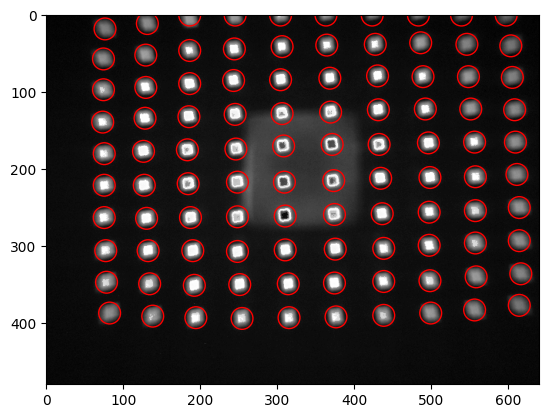

  Processing 0.554 m …


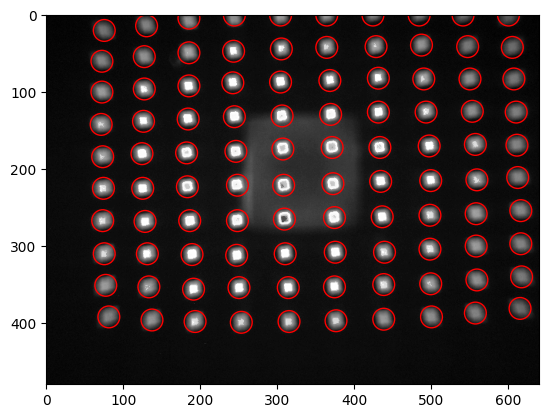

  Processing 0.609 m …


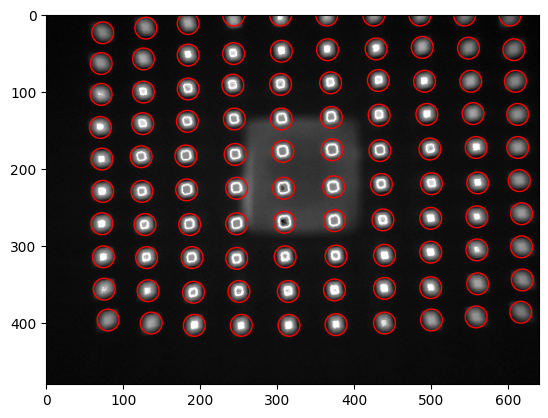

  Processing 0.68 m …


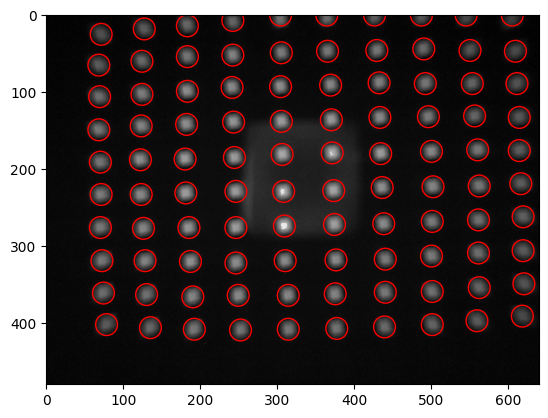

  Processing 0.774 m …


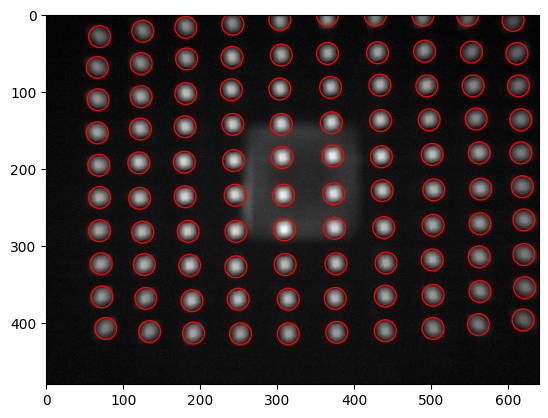

  Processing 0.905 m …


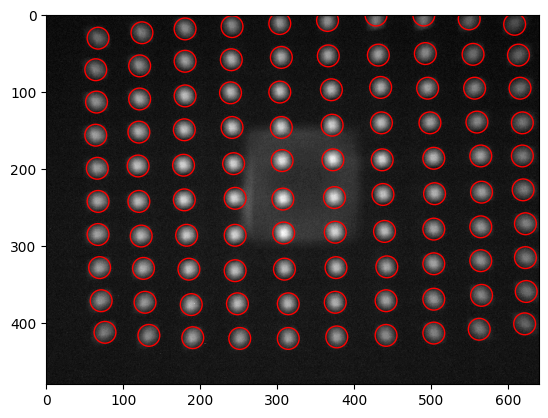

  Processing 1.101 m …


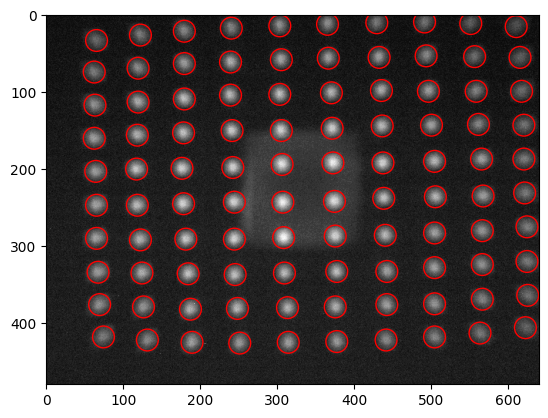


Dots per distance (raw, no grid enforced): [100, 100, 100, 100, 100, 100, 100]
Tracked roster size: 100 dots
IDed dots per distance: [100, 100, 100, 100, 100, 100, 100]


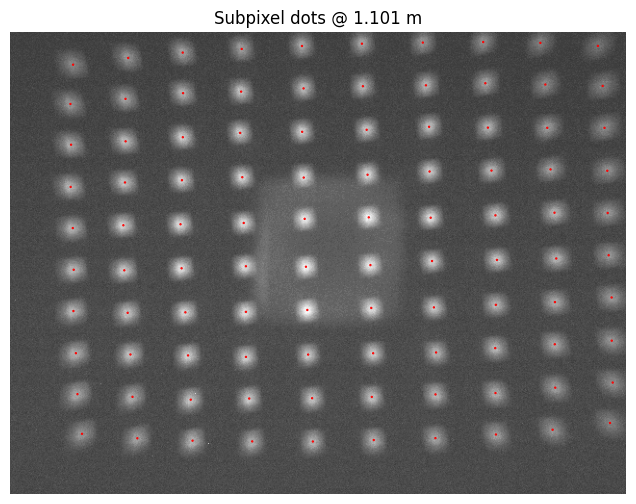

In [2]:
# Collect calibration PCD paths sorted by distance
pcd_files = sorted(
    tof_cal.glob("ToF_*m.pcd"),
    key=lambda p: dotCal.parse_distance_from_name(p.name) or 999.0
)
tof_paths = [str(p) for p in pcd_files]
tof_paths=tof_paths[:-3]
cal_dists = [dotCal.parse_distance_from_name(p) for p in tof_paths]
print(f"Calibration distances: {cal_dists}")

# ── Steps 1+2: LoG blob detection + subpixel refinement (no fixed grid) ──
subpixel_list_unordered = []
for dist in cal_dists:
    print(f"  Processing {dist} m …")
    blobs, image = dotCal.detect_blobs(
        str(sl_cal / f"SL_{dist}m.png"),
        add_synthetic_gaussian=False, visualize=True, **CAL_BLOB_PARAMS)
    _, subpixels = dotCal.detect_subpixel_locations(blobs, image, mode="geometricCenter")
    subpixel_list_unordered.append(subpixels)

print(f"\nDots per distance (raw, no grid enforced): "
      f"{[len(s) for s in subpixel_list_unordered]}")

# ── Step 2b: cross-distance NN tracking → stable IDs (FL_C §4.1) ─────────
coords_list = None
if TRACK_IN_TX_SPACE:
    coords_list = dotCal.tx_space_coords(
        subpixel_list_unordered, tof_paths, K=K, baseline_guess=BASELINE_GUESS)

subpixel_list = dotCal.track_dots_across_distances(
    subpixel_list_unordered, ref_idx=0, threshold_factor=0.5,
    coords_list=coords_list)

n_dots = max(int(d["id"]) for spx in subpixel_list for d in spx) + 1
print(f"Tracked roster size: {n_dots} dots")
print(f"IDed dots per distance: {[len(s) for s in subpixel_list]}")

# ── Visualise last calibration distance ────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(image, cmap="gray", alpha=0.8)
for d in subpixel_list[-1]:
    ax.add_patch(plt.Circle((d["x"], d["y"]), 0.5,
                            edgecolor="red", facecolor="none", linewidth=1))
ax.set_title(f"Subpixel dots @ {cal_dists[-1]} m")
ax.axis("off")
calibration_figures.append(("step1_2_subpixel_dots", fig))
plt.show()


## Calibration Step 3: 3-D Back-Projection

For each detected dot at pixel (u, v), the organised ToF point cloud is sampled
bilinearly to obtain the 3-D point U_ij in camera coordinates.


In [3]:
U, U_tx = dotCal.backproject_calibration_dots(
    subpixel_list, tof_paths, K=K,
    pcd_depth_mode="radial",
    baseline_guess=BASELINE_GUESS
)
print(f"U shape:    {U.shape}     (n_dots × n_dist × xyz)")
print(f"U_tx shape: {U_tx.shape}  (shifted by baseline_guess = {BASELINE_GUESS*100:.5f} cm)")

# ── Plot: SL images with detected dot IDs ──────────────────────────────
exr_files = sorted(sl_cal.glob("*.exr"),
                   key=lambda p: dotCal.parse_distance_from_name(p.name) or 999.0)
render_by_dist = {dotCal.parse_distance_from_name(p.name): str(p) for p in exr_files}

for j, dist in enumerate(cal_dists):
    exr = render_by_dist.get(dist)
    if exr is None:
        continue
    img = dotCal.read_image(exr)
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.imshow(img, cmap="gray")
    for dot in subpixel_list[j]:
        ax.add_patch(plt.Circle((dot["x"], dot["y"]), 2,
                                edgecolor="red", facecolor="none", linewidth=1))
        ax.text(dot["x"] + 2, dot["y"] + 2, str(dot["id"]),
                fontsize=5, color="yellow")
    ax.set_title(f"{dist:.5f} m  |  {len(subpixel_list[j])} dots")
    ax.axis("off")
    calibration_figures.append((f"step3_dotids_{dist}m", fig))
    plt.show()


U shape:    (100, 7, 3)     (n_dots × n_dist × xyz)
U_tx shape: (100, 7, 3)  (shifted by baseline_guess = 3.00000 cm)


## Calibration Step 4: Baseline Estimation

Fit a 3-D line through each dot's multi-distance measurements (in U_tx space),
then find the least-squares intersection of all lines.  The x-component is the
correction to the initial baseline guess, giving AB.

With `BASELINE_OUTLIER_SIGMA` set, outlier rays are removed before the final fit
(FL_C §4.1: "After removing outlier rays, the baseline AB is found by an
additional least squares optimization").


Fitted 100 dot lines
LS intersection (U_tx):  [-0.02897464  0.0450929   0.039636  ]
Baseline AB:  0.10254 cm   →  B = [0.00102536 0.0450929  0.039636  ]
y, z of intersection (0 would mean a purely horizontal baseline): 0.04509, 0.03964


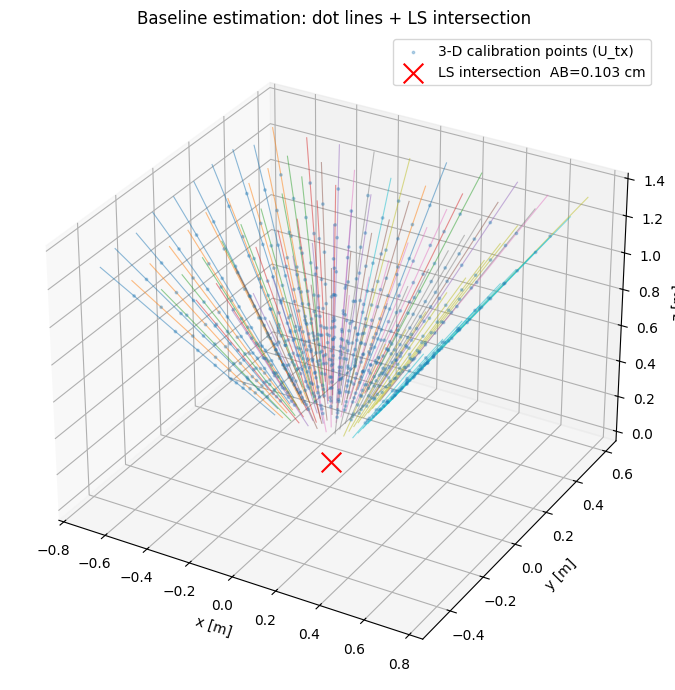

In [4]:
SHOW_DOT_TRAILS = True   # connect same dots across distances with lines
EXTEND_FACTOR   = 0.3    # extend lines 30% beyond endpoints toward intersection

intersection, n_lines = dotCal.estimate_baseline(
    U_tx, outlier_sigma=BASELINE_OUTLIER_SIGMA)

# Full 3-D transmitter position: B_guess (x-only) + the fitted correction.
# The rig need not be purely x-offset, so we keep the fitted y/z instead of
# discarding them — a real y/z misalignment here would otherwise make the
# camera/projector rays used later in triangulate_depth nearly parallel
# (near-zero effective baseline) and the triangulation numerically degenerate.
B_guess = np.array([BASELINE_GUESS, 0.0, 0.0])
B  = B_guess + intersection
AB = float(B[0])

print(f"Fitted {n_lines} dot lines (after outlier removal)" if BASELINE_OUTLIER_SIGMA
      else f"Fitted {n_lines} dot lines")
print(f"LS intersection (U_tx):  {intersection}")
print(f"Baseline AB:  {AB*100:.5f} cm   →  B = {B}")
print(f"y, z of intersection (0 would mean a purely horizontal baseline): "
      f"{float(intersection[1]):.5f}, {float(intersection[2]):.5f}")

# ── 3-D plot: points + lines + intersection ─────────────────────────────
all_pts = U_tx.reshape(-1, 3)
all_pts = all_pts[np.all(np.isfinite(all_pts), axis=1)]

fig = plt.figure(figsize=(10, 7))
ax  = fig.add_subplot(111, projection="3d")
ax.scatter(all_pts[:, 0], all_pts[:, 1], all_pts[:, 2],
           s=3, alpha=0.3, label="3-D calibration points (U_tx)")

if SHOW_DOT_TRAILS:
    cmap = plt.cm.tab10
    for i in range(U_tx.shape[0]):
        pts = U_tx[i, :, :]
        valid = np.all(np.isfinite(pts), axis=1)
        if valid.sum() < 2:
            continue
        pts_v = pts[valid]
        direction = pts_v[-1] - pts_v[0]
        start = pts_v[0] - EXTEND_FACTOR * direction
        end   = pts_v[-1] + EXTEND_FACTOR * direction
        extended = np.vstack([start[None, :], pts_v, end[None, :]])
        ax.plot(extended[:, 0], extended[:, 1], extended[:, 2],
                color=cmap(i % 10), alpha=0.5, linewidth=0.8)

ax.scatter(*intersection, s=200, marker="x", color="red",
           label=f"LS intersection  AB={AB*100:.3f} cm")
ax.set_title("Baseline estimation: dot lines + LS intersection")
ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]"); ax.set_zlabel("z [m]")
ax.legend()
plt.tight_layout()
calibration_figures.append(("step4_baseline_3d", fig))
plt.show()


## Calibration Step 5: Unit Vector Estimation

For each dot i, fit a unit direction vector V[i] by minimising the angle between
the fitted ray and each calibration point Q_ij = U_ij − B.


Unit vectors estimated: 100 / 100


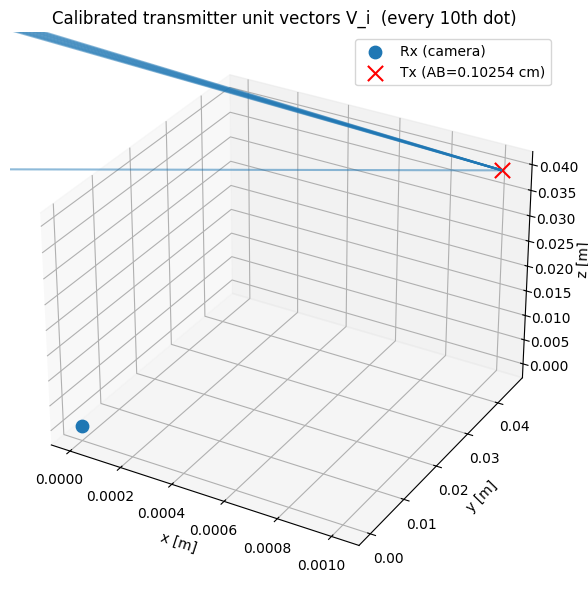

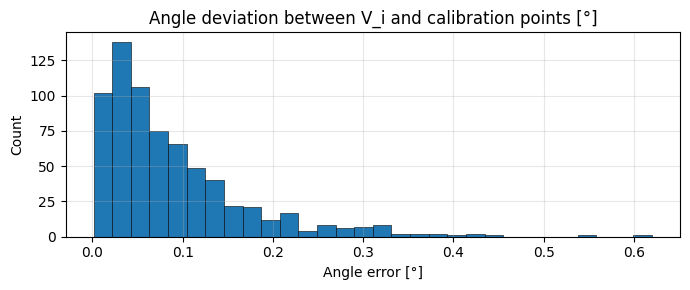

Median angle error: 0.06342°
Max angle error:    0.62002°


In [5]:
V = dotCal.estimate_unit_vectors(U, B)
V_valid = V[np.all(np.isfinite(V), axis=1)]
print(f"Unit vectors estimated: {len(V_valid)} / {V.shape[0]}")

# Angle-error diagnostics
angle_errs = []
for i in range(V.shape[0]):
    if not np.all(np.isfinite(V[i])):
        continue
    pts   = U[i, :, :]
    valid = np.all(np.isfinite(pts), axis=1)
    Q     = pts[valid] - B[None, :]
    Qn    = Q / (np.linalg.norm(Q, axis=1, keepdims=True) + 1e-12)
    angle_errs.extend(np.degrees(np.arccos(np.clip(Qn @ V[i], -1, 1))).tolist())

# ── Quiver plot ────────────────────────────────────────────────────────
fig = plt.figure(figsize=(9, 6))
ax  = fig.add_subplot(111, projection="3d")
ax.scatter([0], [0], [0], s=80, marker="o", label="Rx (camera)")
ax.scatter([B[0]], [B[1]], [B[2]], s=120, marker="x", color="red", label=f"Tx (AB={AB*100:.5f} cm)")
for i in range(0, V.shape[0], 10):
    if not np.all(np.isfinite(V[i])):
        continue
    ax.quiver(B[0], B[1], B[2], V[i, 0], V[i, 1], V[i, 2],
              length=0.4, normalize=True, alpha=0.5)
ax.set_title("Calibrated transmitter unit vectors V_i  (every 10th dot)")
ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]"); ax.set_zlabel("z [m]")
ax.legend()
plt.tight_layout()
calibration_figures.append(("step5_unit_vectors", fig))
plt.show()

# ── Angle-error histogram ─────────────────────────────────────────────
plt.figure(figsize=(7, 3))
plt.hist(np.array(angle_errs), bins=30, edgecolor="k", linewidth=0.4)
plt.title("Angle deviation between V_i and calibration points [°]")
plt.xlabel("Angle error [°]"); plt.ylabel("Count")
plt.grid(alpha=0.3); plt.tight_layout()
calibration_figures.append(("step5_angle_error_hist", plt.gcf()))
plt.show()

print(f"Median angle error: {np.median(angle_errs):.5f}°")
print(f"Max angle error:    {np.max(angle_errs):.5f}°")


## Save Calibration

Save all calibration data (V, B, K, subpixel_list, etc.) to a JSON file in
`Calibrations/<name>/calibration.json`. Optionally save all calibration plots as PNGs.
The saved file is directly usable by `approaches.py` / `run_all.py`.


In [6]:
import json as _json
from datetime import datetime as _dt

# ── User input ──────────────────────────────────────────────────────────
cal_name   = input("Calibration name: ").strip()
save_plots = input("Save calibration plots? (y/n): ").strip().lower() == "y"

assert cal_name, "Calibration name must not be empty."

cal_dir = Path.cwd().parent / "Calibrations" / cal_name
cal_dir.mkdir(parents=True, exist_ok=True)

# ── NaN-safe JSON serialization ─────────────────────────────────────────
def _sanitize(obj):
    """Recursively replace NaN/Inf with None for JSON compatibility."""
    if isinstance(obj, float):
        return None if (np.isnan(obj) or np.isinf(obj)) else obj
    if isinstance(obj, (np.floating,)):
        v = float(obj)
        return None if (np.isnan(v) or np.isinf(v)) else v
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, np.ndarray):
        return _sanitize(obj.tolist())
    if isinstance(obj, list):
        return [_sanitize(x) for x in obj]
    if isinstance(obj, dict):
        return {k: _sanitize(v) for k, v in obj.items()}
    return obj

cal_data = _sanitize({
    "metadata": {
        "created": _dt.now().isoformat(),
        "camera": "Schmersal" if Schmersal else "OnSemi",
        "sl_cal_path": str(sl_cal),
        "tof_cal_path": str(tof_cal),
        "baseline_guess": BASELINE_GUESS,
        "subpixel_mode": "geometricCenter",
        "pcd_depth_mode": "radial",
        "pcd_unit_scale": 0.001,
        "track_in_tx_space": TRACK_IN_TX_SPACE,
        "baseline_outlier_sigma": BASELINE_OUTLIER_SIGMA,
        "blob_params": TEST_BLOB_PARAMS,   # used by approaches.py at test time
        "fx": float(fx), "fy": float(fy),
        "cx": float(cx), "cy": float(cy),
    },
    "K": K.tolist(),
    "K_inv": K_inv.tolist(),
    "V": V.tolist(),
    "B": B.tolist(),
    "AB": float(AB),
    "BASELINE_GUESS": float(BASELINE_GUESS),
    "cal_dists": [float(d) for d in cal_dists],
    "subpixel_list": subpixel_list,
    "U": U.tolist(),
})

cal_file = cal_dir / "calibration.json"
with open(cal_file, "w") as f:
    _json.dump(cal_data, f)
print(f"Calibration saved to {cal_file}")

if save_plots:
    for name, fig in calibration_figures:
        fig.savefig(str(cal_dir / f"{name}.png"), dpi=150, bbox_inches="tight")
    print(f"Saved {len(calibration_figures)} plot(s) to {cal_dir}")


AssertionError: Calibration name must not be empty.

## Test Scene Setup

Load the test scene, detect dots (no grid) and build the calibration trails +
trail KD-tree once — shared by all four approaches via `approaches.common_setup`.


Ground-truth distance: 0.61 m
Detected dots in test SL: 102


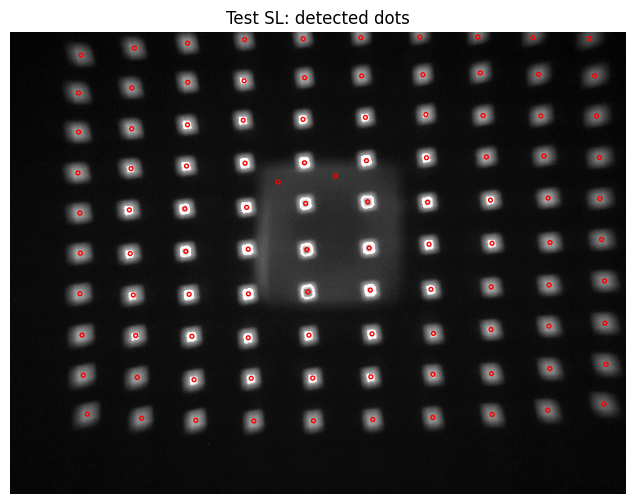

In [11]:
suffix = "Schm" if Schmersal else "On"
SL_TEST  = str(test_dir / f"SL_0.61m.png")
TOF_TEST = str(test_dir / f"ToF_0.61m.pcd")

# Ground truth from filename → enables average-error printout per approach
approaches.GT_DISTANCE = approaches._parse_gt_distance(SL_TEST)
print(f"Ground-truth distance: {approaches.GT_DISTANCE} m")

# In-memory calibration dict (same structure as a loaded calibration.json)
cal = {
    "K": K, "K_inv": K_inv, "V": V, "B": B,
    "AB": float(AB), "BASELINE_GUESS": float(BASELINE_GUESS),
    "U": U, "cal_dists": [float(d) for d in cal_dists],
    "subpixel_list": subpixel_list,
    "metadata": {"pcd_unit_scale": 0.001, "blob_params": TEST_BLOB_PARAMS},
}

setup = approaches.common_setup(dotCal, cal, SL_TEST, TOF_TEST)

fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(setup["sl_gray"], cmap="gray")
for u, v in setup["test_uv"]:
    ax.add_patch(plt.Circle((u, v), 2, edgecolor="red", facecolor="none", linewidth=1))
ax.set_title("Test SL: detected dots"); ax.axis("off"); plt.show()


## Approach 1: Consistency Error  (Microsoft-Paper)

At test time, each detected dot is assigned to its closest calibration trail.
The trail is sampled at all calibration distances.  For each sample j along the
trail, both Z_ToF(j) and Z_triangulation(j) are computed.  The sample
j\* = argmin ε, with **ε = |1/Z_ToF − 1/Z_tri|**, is selected; the output depth
is the **ToF depth** at that sample (FL_C §4.2).


Approach 1: processed 100 dots
  ε range: 3.910e-03 – 1.197e-01
  dot   0  i*= 64  j*= 6  Z_raw=1.0173  Z_out=1.0195  ε*=7.260e-02
  dot   1  i*= 52  j*= 6  Z_raw=1.0097  Z_out=1.0079  ε*=1.002e-01
  dot   2  i*= 42  j*= 6  Z_raw=1.0015  Z_out=0.9998  ε*=9.797e-02
  dot   3  i*= 45  j*= 6  Z_raw=1.0227  Z_out=1.0219  ε*=1.023e-01
  dot   4  i*= 46  j*= 5  Z_raw=1.0149  Z_out=1.0134  ε*=9.659e-02
  dot   5  i*= 54  j*= 5  Z_raw=1.0215  Z_out=1.0197  ε*=3.284e-02
  dot   6  i*= 62  j*= 5  Z_raw=1.0132  Z_out=1.0172  ε*=1.000e-01
  dot   7  i*= 41  j*= 6  Z_raw=1.0018  Z_out=1.0036  ε*=8.709e-02
  dot   8  i*= 33  j*= 6  Z_raw=1.0055  Z_out=1.0066  ε*=9.556e-02
  dot   9  i*= 63  j*= 6  Z_raw=1.0164  Z_out=1.0175  ε*=6.900e-02
  dot  10  i*= 55  j*= 5  Z_raw=1.0225  Z_out=1.0188  ε*=8.636e-02
  dot  11  i*= 65  j*= 6  Z_raw=1.0197  Z_out=1.0200  ε*=9.241e-02
  dot  12  i*= 44  j*= 5  Z_raw=1.0147  Z_out=1.0114  ε*=9.275e-02
  dot  13  i*= 22  j*= 6  Z_raw=0.9988  Z_out=1.0007  ε*=9.201e-0

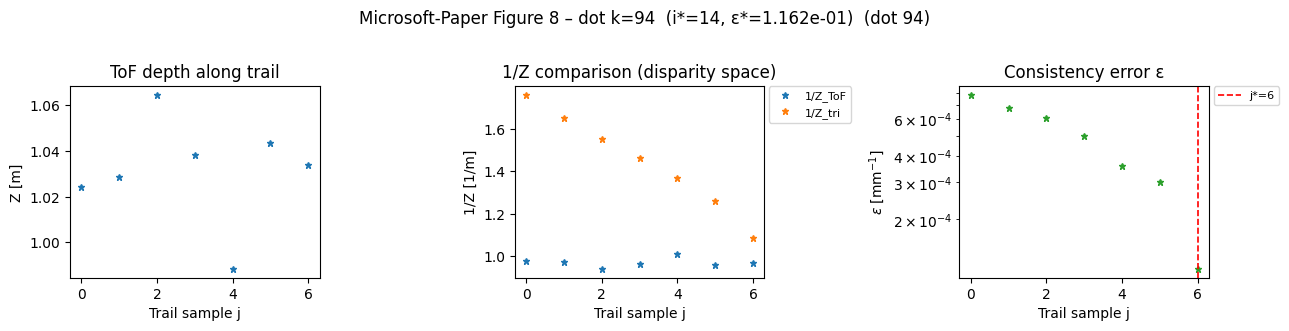

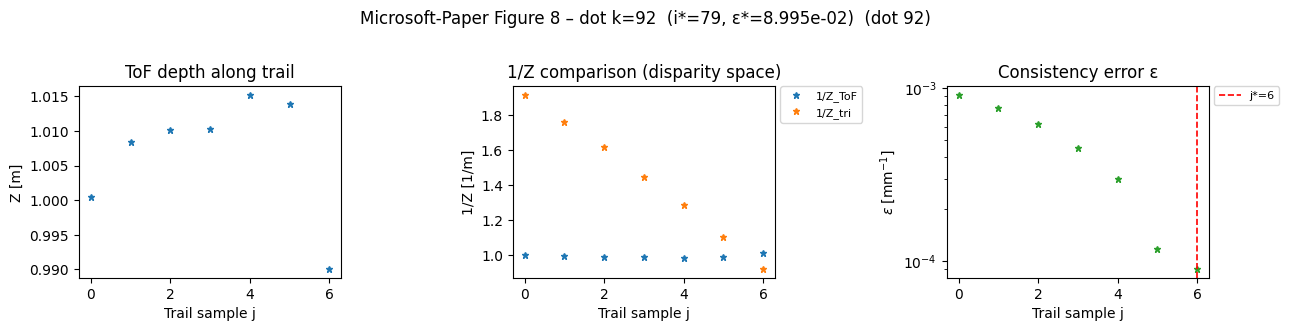

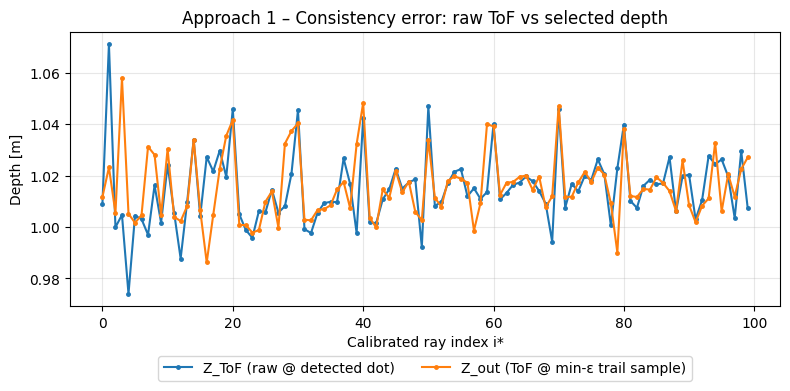

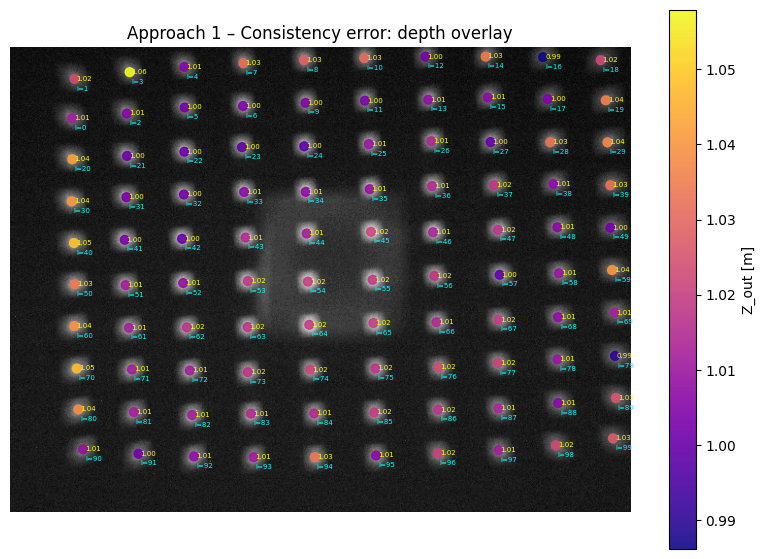

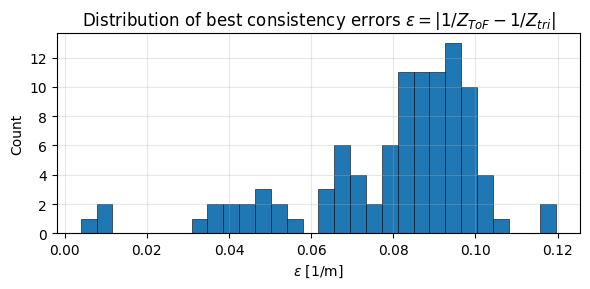

In [8]:
res1 = approaches.run_approach_1(dotCal, cal, setup, make_plots=True)
approaches.print_average_error(1, res1["depths"])
plt.show()


## Approach 2: Maximum Likelihood Fusion  (Agresti & Zanuttigh, ECCV 2018)

ToF and SL (triangulation) depth estimates are combined via maximum likelihood
using spatially-weighted mixture-of-Gaussians likelihoods (Agresti eq. 16/17).
Dot-sparse adaptation: the dense 7×7 pixel patch of the paper is replaced by the
k nearest detected dots; σ_ToF/σ_SL are heuristic models (σ_SL keeps the paper's
quadratic growth with depth).


Approach 2 – ToF valid: 100 / 100  range: 0.97–1.07 m
Approach 2 – SL  valid: 100 / 100  range: 0.86–1.13 m
Approach 2 – Fused valid: 100 / 100  range: 0.99–1.05 m
  dot   0  i*= 64  Z_tof=1.0173  Z_sl=1.0122  Z_fus=1.0166
  dot   1  i*= 52  Z_tof=1.0097  Z_sl=1.0316  Z_fus=1.0157
  dot   2  i*= 42  Z_tof=1.0015  Z_sl=1.0181  Z_fus=1.0071
  dot   3  i*= 45  Z_tof=1.0227  Z_sl=1.0398  Z_fus=1.0274
  dot   4  i*= 46  Z_tof=1.0149  Z_sl=1.0492  Z_fus=1.0243
  dot   5  i*= 54  Z_tof=1.0215  Z_sl=1.1266  Z_fus=1.0191
  dot   6  i*= 62  Z_tof=1.0132  Z_sl=1.0446  Z_fus=1.0211
  dot   7  i*= 41  Z_tof=1.0018  Z_sl=1.0133  Z_fus=1.0058
  dot   8  i*= 33  Z_tof=1.0055  Z_sl=1.0377  Z_fus=1.0151
  dot   9  i*= 63  Z_tof=1.0164  Z_sl=1.0229  Z_fus=1.0186
  dot  10  i*= 55  Z_tof=1.0225  Z_sl=1.0694  Z_fus=1.0299
  dot  11  i*= 65  Z_tof=1.0197  Z_sl=1.0428  Z_fus=1.0266
  dot  12  i*= 44  Z_tof=1.0147  Z_sl=1.0534  Z_fus=1.0260
  dot  13  i*= 22  Z_tof=0.9988  Z_sl=1.0270  Z_fus=1.0073
  dot  14 

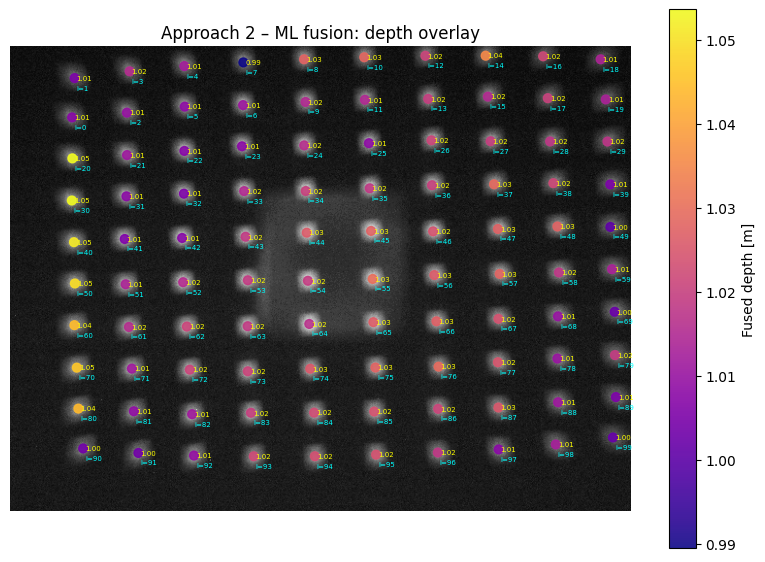

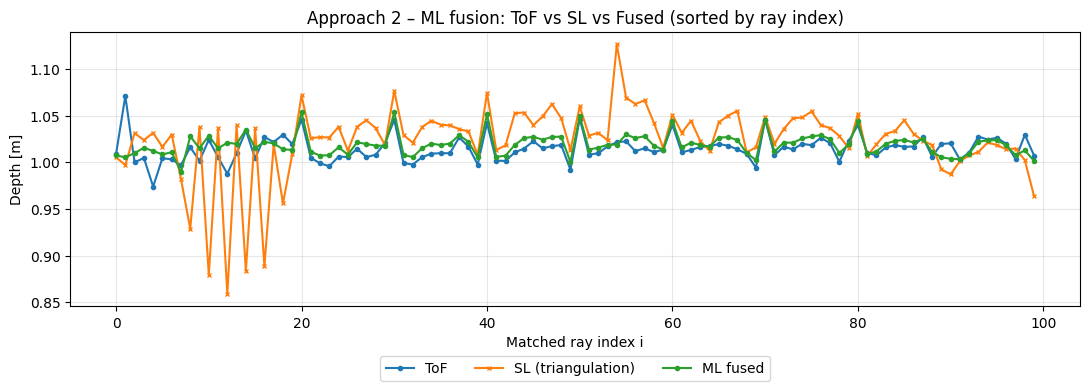

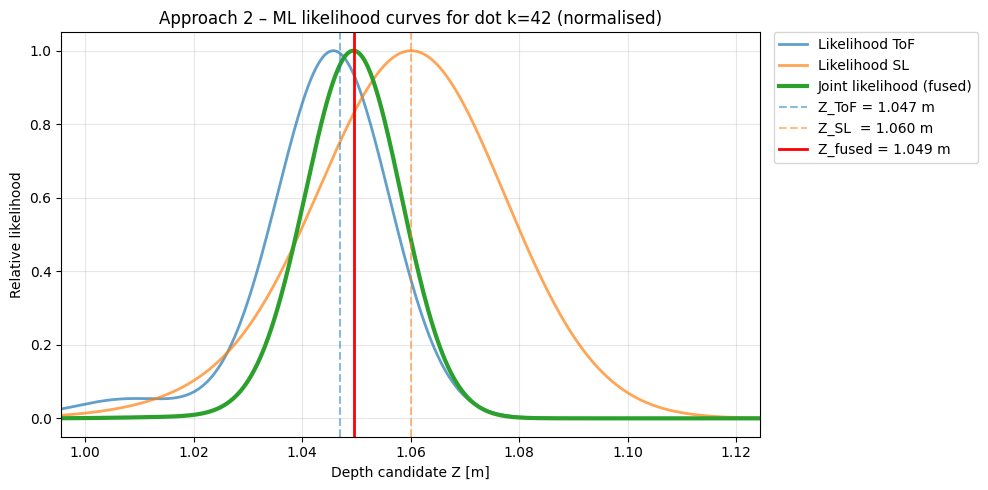

In [9]:
res2 = approaches.run_approach_2(dotCal, cal, setup, make_plots=True)
approaches.print_average_error(2, res2["depths"])
plt.show()


## Approach 3: Active Brightness Trail  (Microsoft-Paper §4.2)

Implemented as an **epipolar-line scan**: the calibration trails are nearly
horizontal, so the active-brightness search runs on image rows.

1. Assign the detected dot to the nearest calibration trail / projector ray `V[i]`
2. Select the epipolar row from that dot's own calibration trail
3. Detect active-brightness peaks on that full image row
4. Evaluate `ε = |1/Z_ToF − 1/Z_tri|` at each row peak
5. Select the peak with minimum ε
6. Refine the selected column with a quadratic sub-pixel fit
7. Output the **triangulated** depth at `(u_sub, row)`


In [ ]:
res3 = approaches.run_approach_3(dotCal, cal, setup, make_plots=True)
approaches.print_average_error(3, res3["depths"])
plt.show()


## Approach 4: Consistency-Error-Guided Triangulation

Same pipeline as Approach 1, but the **output depth is the triangulated depth**
at the detected dot position, not the ToF depth.  ε only identifies the correct
trail position / gates outliers; the final depth comes from triangulation, which
is MPI-free.

Part A additionally estimates the dot localisation error δx via forward
projection and validates the empirical triangulation depth error against the
theoretical bound δz = δx·z²/(B·h).


Forward-projection localisation error (RMS):
  dx = 2.0493 px  =  20.49 µm
  Physical focal length h = 5.031 mm
  Baseline AB = 0.103 cm
  Total residual samples: 700

Forward-projection residuals by distance:
  Dist [m]   RMS [px]     N
       0.5     3.1931   100
       0.6     2.5991   100
       0.6     2.2010   100
       0.7     1.6157   100
       0.8     1.3786   100
       0.9     1.2641   100
       1.1     1.2221   100

Empirical triangulation depth error at calibration distances:
  Dist [m]  Mean [mm]   Std [mm]   RMS [mm]     N
       0.5       6.49      16.63      17.85   100
       0.6       6.97      13.83      15.49   100
       0.6       5.29       9.04      10.47   100
       0.7       6.79       8.61      10.96   100
       0.8       5.41      16.33      17.20   100
       0.9       4.77      30.74      31.11   100
       1.1       3.65      48.90      49.04   100

Theoretical triangulation depth error  dz = dx·z²/(AB·h):
  z = 0.5 m  →  dz = 99.32 cm  (993.2 mm)
  

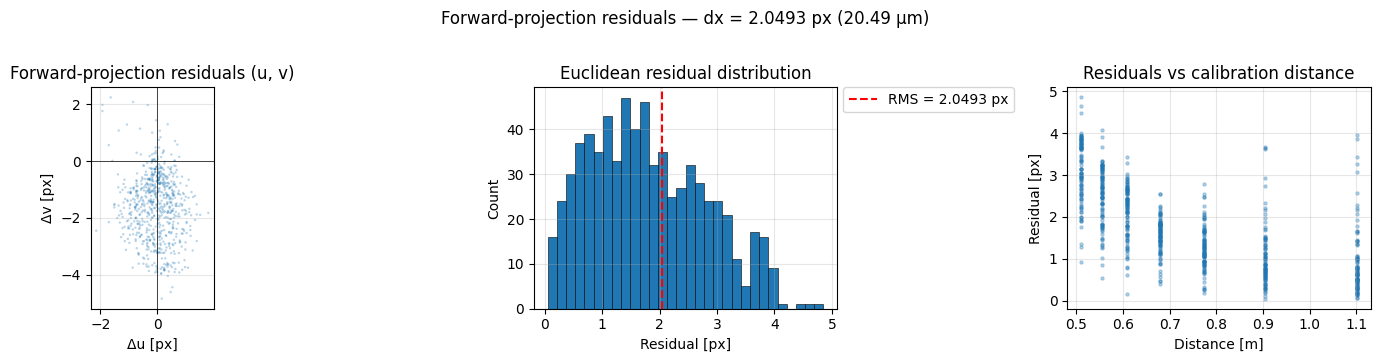

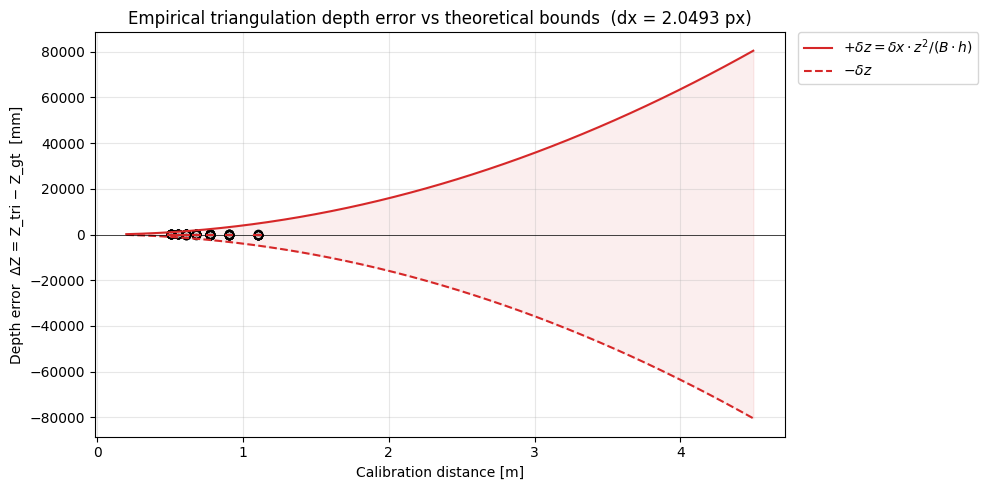

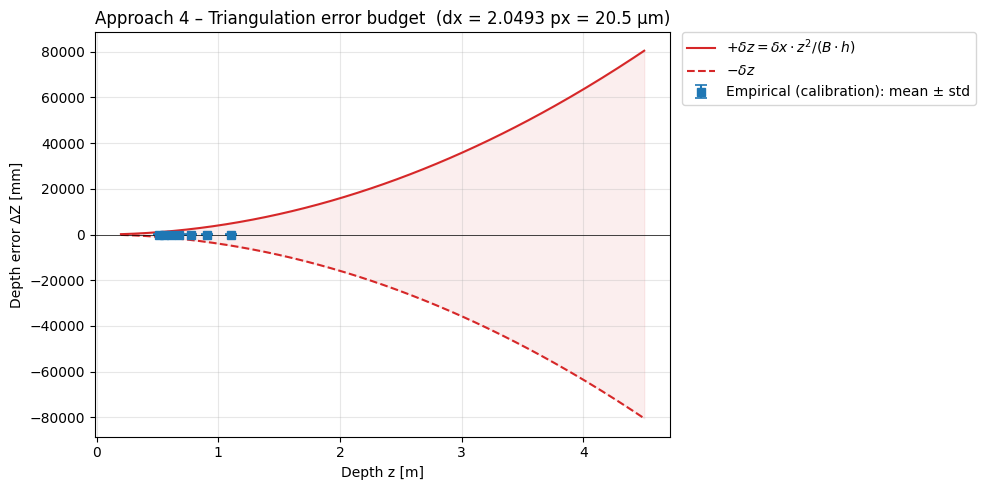

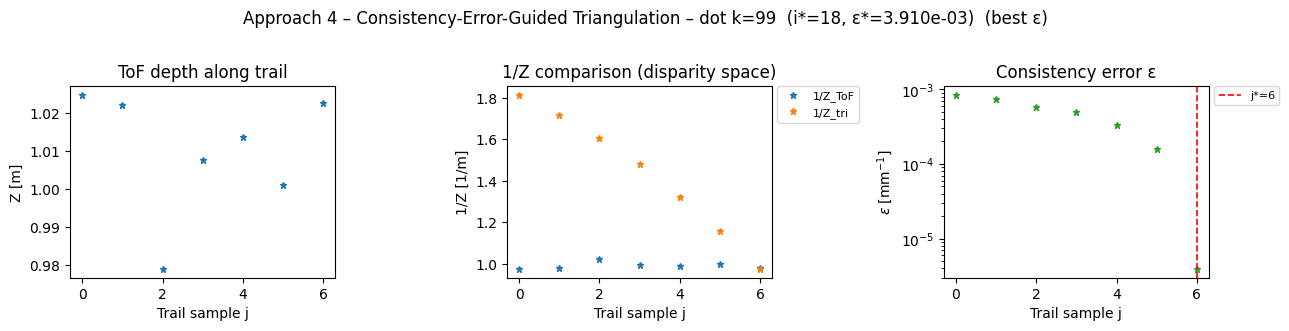

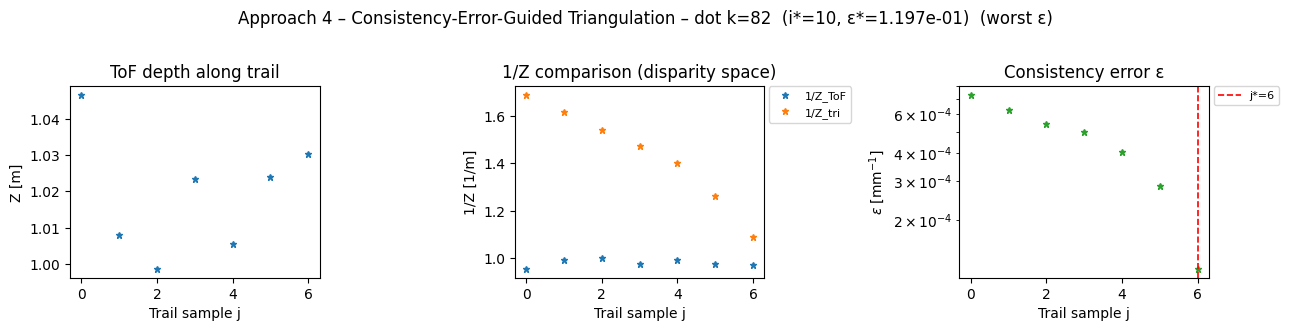

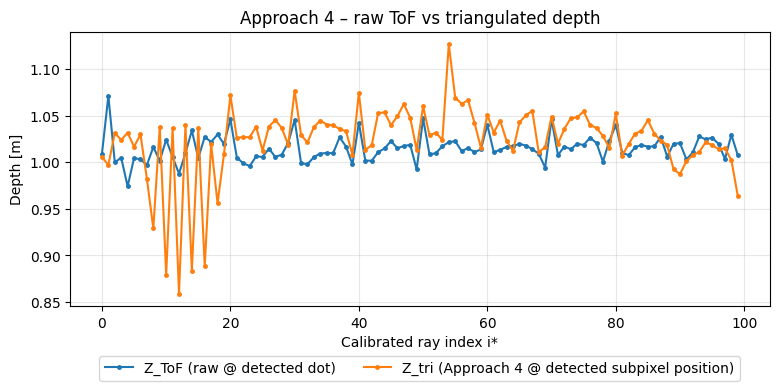

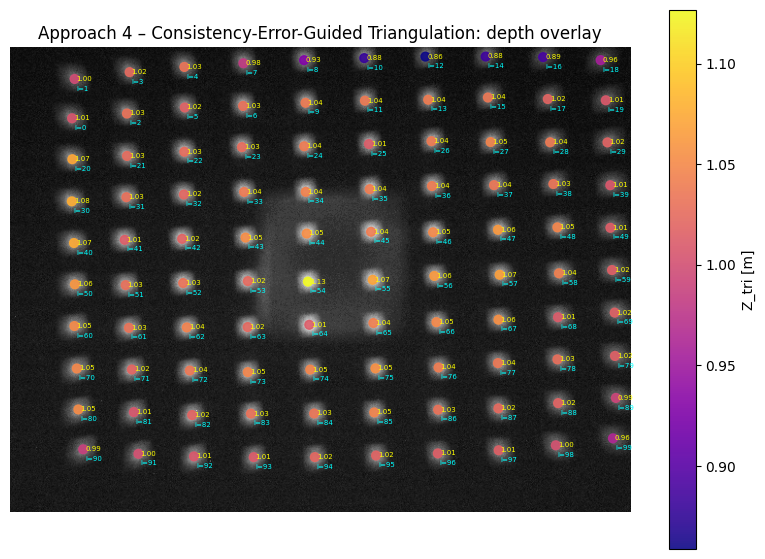

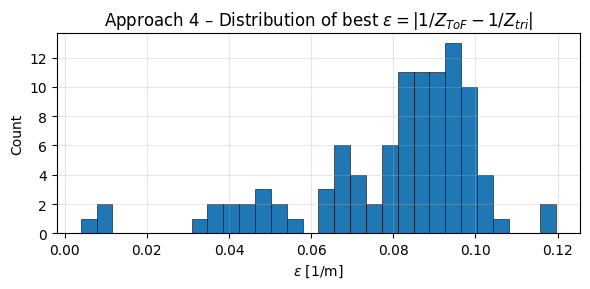

In [10]:
res4 = approaches.run_approach_4(dotCal, cal, setup, make_plots=True)
approaches.print_average_error(4, res4["depths"])
plt.show()
